# Pretrained MNIST Diffusion Inference

This notebook avoids training a tiny bad model from scratch.

Instead it uses:

1. a pretrained MNIST DDPM generator
2. a pretrained MNIST digit classifier
3. classifier-based filtering to get a requested digit

This is not true text-guided diffusion. It is a practical shortcut:

```text
generate many MNIST-like digits -> classify them -> keep the ones classified as the requested digit
```

That gives much better results than the tiny educational latent diffusion model.


## 0. Install dependencies

Run this once if the packages are missing.


In [ ]:
# Uncomment if needed:
# !pip install -q diffusers transformers accelerate safetensors pillow matplotlib

In [1]:
import math
import re

import matplotlib.pyplot as plt
import torch
from diffusers import DDPMPipeline
from transformers import pipeline as hf_pipeline

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda


## 1. Load pretrained models

- `1aurent/ddpm-mnist`: pretrained unconditional MNIST DDPM generator
- `farleyknight/mnist-digit-classification-2022-09-04`: pretrained MNIST classifier


In [ ]:
generator_model_id = "1aurent/ddpm-mnist"
classifier_model_id = "farleyknight/mnist-digit-classification-2022-09-04"

ddpm = DDPMPipeline.from_pretrained(generator_model_id).to(device)

# transformers pipeline uses device index: 0 for CUDA, -1 for CPU
classifier = hf_pipeline(
    "image-classification",
    model=classifier_model_id,
    device=0 if device == "cuda" else -1,
)


## 2. Utility functions


In [3]:
def show_grid(images, titles=None, cols=8, figsize=None):
    """Display PIL images in a compact grid."""
    n = len(images)
    rows = math.ceil(n / cols)
    if figsize is None:
        figsize = (cols * 1.4, rows * 1.6)

    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.flatten() if n > 1 else [axes]

    for i, ax in enumerate(axes):
        ax.axis("off")
        if i < n:
            ax.imshow(images[i], cmap="gray")
            if titles is not None:
                ax.set_title(titles[i], fontsize=9)

    plt.tight_layout()
    plt.show()


def parse_digit(label):
    """Handle labels like '7', 'LABEL_7', or 'digit 7'."""
    match = re.search(r"\d", str(label))
    return int(match.group()) if match else None


def classify_batch(images):
    """Return top-10 classifier predictions for each PIL image."""
    preds = classifier(images, top_k=10)

    # If a single image is passed, HF returns list[dict]; for many images it returns list[list[dict]].
    if len(images) == 1 and isinstance(preds[0], dict):
        preds = [preds]

    return preds


def top_prediction(preds_for_one_image):
    best = preds_for_one_image[0]
    return parse_digit(best["label"]), float(best["score"])


def score_for_digit(preds_for_one_image, digit):
    for item in preds_for_one_image:
        if parse_digit(item["label"]) == digit:
            return float(item["score"])
    return 0.0


## 3. Generate unconditional MNIST digits

The generator is unconditional, so it produces random digits. You cannot directly ask it for `"digit 7"`.


  0%|          | 0/100 [00:00<?, ?it/s]

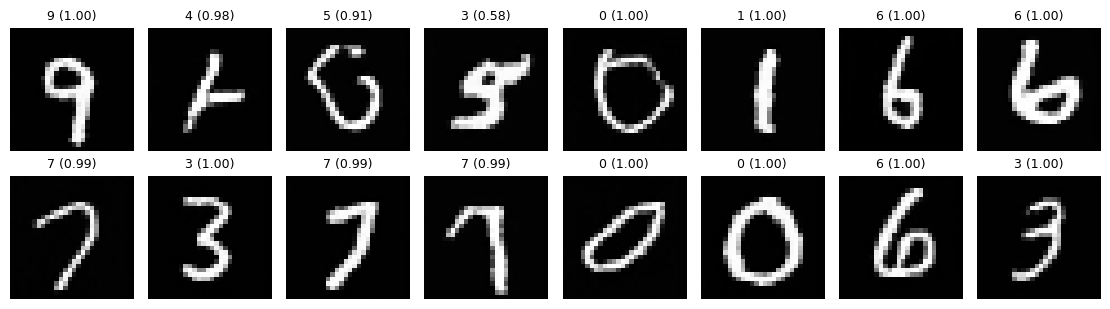

In [4]:
seed = 0
torch_gen = torch.Generator(device=device).manual_seed(seed)

images = ddpm(
    batch_size=16,
    num_inference_steps=100,
    generator=torch_gen,
).images

preds = classify_batch(images)
titles = []
for p in preds:
    digit, score = top_prediction(p)
    titles.append(f"{digit} ({score:.2f})")

show_grid(images, titles=titles, cols=8)


## 4. Ask for a digit by filtering generated samples

This is a simple rejection/filtering method:

```text
target digit -> generate many candidates -> classify candidates -> keep highest-confidence target samples
```

Increasing `n_candidates` improves the chance of getting clean requested digits.


In [5]:
def generate_requested_digit(
    digit,
    n_candidates=64,
    keep=8,
    num_inference_steps=100,
    seed=123,
):
    assert 0 <= digit <= 9

    torch_gen = torch.Generator(device=device).manual_seed(seed)
    images = ddpm(
        batch_size=n_candidates,
        num_inference_steps=num_inference_steps,
        generator=torch_gen,
    ).images

    preds = classify_batch(images)

    ranked = []
    for img, pred in zip(images, preds):
        top_digit, top_score = top_prediction(pred)
        target_score = score_for_digit(pred, digit)
        ranked.append({
            "image": img,
            "top_digit": top_digit,
            "top_score": top_score,
            "target_score": target_score,
        })

    ranked = sorted(ranked, key=lambda x: x["target_score"], reverse=True)
    chosen = ranked[:keep]
    return chosen


  0%|          | 0/100 [00:00<?, ?it/s]

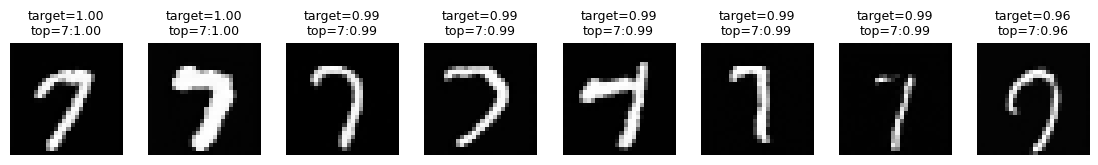

In [6]:
target_digit = 7

chosen = generate_requested_digit(
    digit=target_digit,
    n_candidates=96,
    keep=8,
    num_inference_steps=100,
    seed=7,
)

images = [x["image"] for x in chosen]
titles = [
    f"target={x['target_score']:.2f}\ntop={x['top_digit']}:{x['top_score']:.2f}"
    for x in chosen
]

show_grid(images, titles=titles, cols=8)


## 5. Generate all digits

This loops over `0..9`, generates candidates for each target, and keeps the best one.


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  0%|          | 0/100 [00:00<?, ?it/s]

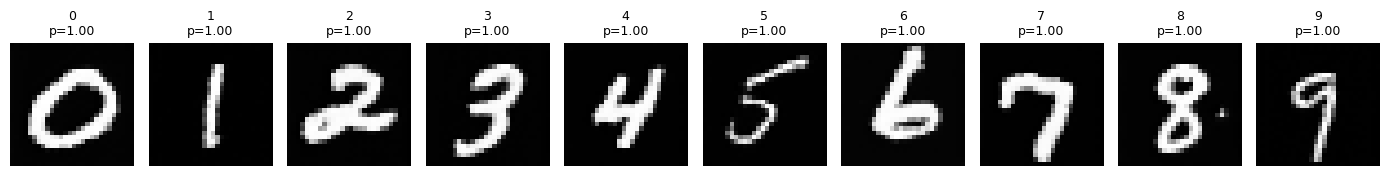

In [ ]:
best_images = []
titles = []

for d in range(10):
    chosen = generate_requested_digit(
        digit=d,
        n_candidates=32,
        keep=1,
        num_inference_steps=100,
        seed=100 + d,
    )
    best = chosen[0]
    best_images.append(best["image"])
    titles.append(f"{d}\np={best['target_score']:.2f}")

show_grid(best_images, titles=titles, cols=10, figsize=(14, 2))
